In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p

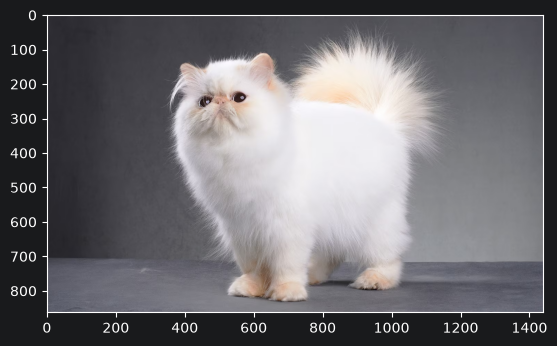

In [2]:
img_path = p.IMAGE_ASSETS / "cat1.png"
img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(img_rgb)

In [3]:
def draw_points(src: np.ndarray, points: np.ndarray, color=(255, 0, 0)):
    src = src.copy()

    if points.dtype != np.int64:
        points = points.astype(np.int64)

    for i in range(points.shape[0]):
        cv2.circle(src, points[i], 3, color, -1)
        cv2.putText(src,
                    f"p_{i}",
                    (points[i, 0] + 10, points[i, 1]),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1, (0, 255, 0), 2)

    return src

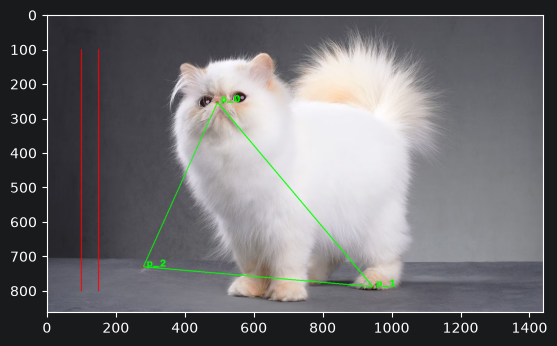

In [4]:
height, width, _ = img_rgb.shape

p1 = np.array([[495, 253],
               [946, 788],
               [280, 730]], dtype=np.float32)

marked_img = draw_points(img_rgb, p1)

# add parallel lines for exemple that affine transformation save parallel lines
for i in range(0, 51, 50):
    cv2.line(marked_img, (100 + i, 100), (100 + i, 800), (255, 0, 0), 2)

cv2.polylines(marked_img, [p1.astype(np.int64)], True, (0, 255, 0), 2)

plt.figure()
plt.imshow(marked_img)



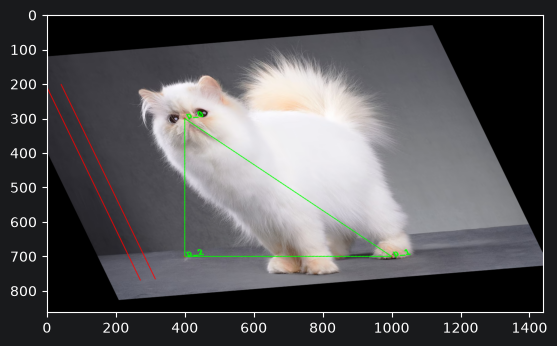

In [5]:
p2 = np.array([[400, 300],
               [1000, 700],
               [400, 700]], dtype=np.float32)


T = cv2.getAffineTransform(p1, p2)

transformed = cv2.warpAffine(marked_img, T, (width, height))

plt.figure()
plt.imshow(transformed)